# CONFLUENCE Tutorial - 4: Semi-Distributed Basin Workflow (East River at Banff)

## Introduction
This tutorial demonstrates the next advancement in spatial modeling complexity through semi-distributed basin modeling. Building on the lumped basin approach from Tutorial 02a, we now introduce spatial discretization by dividing the watershed into multiple connected units called Grouped Response Units (GRUs). This approach bridges the gap between simple lumped models and fully distributed representations, offering an optimal balance between computational efficiency and spatial realism.

## Semi-Distributed Modeling Philosophy
Semi-distributed modeling divides the watershed into multiple sub-basins, with each unit treated as a separate modeling component within a connected network. This approach employs spatial discretization where the watershed is divided into multiple GRUs based on stream network topology, creating connected units where each GRU links to downstream units through a routing network. The methodology represents intermediate complexity that provides more spatial realism than lumped models while maintaining greater simplicity than fully distributed approaches, ensuring computational efficiency with fewer units than fully distributed models while remaining suitable for calibration and uncertainty analysis.

## Key Scientific Concepts
The Grouped Response Unit concept represents sub-basins that drain to specific points along the stream network, with each GRU containing similar hydrological characteristics and responding as a unified computational unit. Stream network delineation employs digital elevation models and flow accumulation algorithms to automatically identify stream channels and divide the watershed into connected sub-basins. Routing processes move water from upstream GRUs to downstream GRUs through the stream network while accounting for travel time and channel storage effects. The stream threshold parameter critically controls model complexity by determining how many sub-basins are created, with higher thresholds producing fewer, larger GRUs.

## Scientific Advantages and Applications
Semi-distributed modeling captures important spatial variations in climate, topography, and land cover across the watershed while better representing elevation-dependent processes like snow accumulation and temperature gradients. This approach maintains computational efficiency with fewer units than fully distributed models while preserving key spatial patterns, explicitly represents routing dynamics including travel time and attenuation effects in the stream network, and provides diagnostic capabilities that allow examination of contributions from different watershed regions.

## Case Study: East River at Banff Semi-Distributed Configuration
For this tutorial, we employ the same East River watershed from Tutorial 02a but divide it into multiple GRUs through several configuration modifications. The domain method changes from lumped to delineate for watershed subdivision, a stream threshold of 5000 creates multiple sub-basins, mizuRoute provides routing connectivity between GRUs, and spatial complexity increases from single-unit to multi-unit representation. Expected outcomes include better representation of elevation gradients, improved timing of snowmelt contributions, more realistic representation of spatial climate variability, and enhanced ability to diagnose spatial process patterns.

## Technical Implementation Framework
The semi-distributed approach integrates several key components through automated watershed delineation that identifies sub-basins using flow accumulation algorithms, stream network extraction that creates river network topology connecting the sub-basins, GRU characterization that calculates average characteristics for each sub-basin, routing setup that configures mizuRoute to move water between GRUs, and model integration that couples SUMMA land surface processes with mizuRoute routing capabilities.

## Learning Objectives and Tutorial Structure
Through this tutorial, you will master configuration of semi-distributed models with multiple GRUs, understand control of spatial discretization using stream threshold parameters, comprehend routing processes and their impact on streamflow timing, develop skills in visualizing spatial model structure with GRUs and stream networks, learn to interpret distributed model results and compare with lumped approaches, and manage increased model complexity while maintaining workflow efficiency.

This tutorial follows the established CONFLUENCE workflow with key modifications for spatial complexity, including project setup initialization for semi-distributed modeling, domain delineation to create multiple sub-basins using stream network analysis, spatial discretization to convert sub-basins to GRUs for modeling, data processing to prepare inputs for multiple modeling units, model configuration to set up coupled SUMMA and mizuRoute systems, model execution to run the integrated land surface and routing model, and comprehensive results analysis comparing semi-distributed versus lumped model performance. By completing this tutorial, you will understand how to add spatial complexity to hydrological models while maintaining computational efficiency, establishing crucial foundations for fully distributed modeling applications.

## Step 1: Semi-Distributed Setup with Data Reuse
Building on the lumped basin modeling from Tutorial 02a, we now advance to semi-distributed watershed modeling. This represents an optimal balance between computational efficiency and spatial realism: multiple connected sub-basins that capture key spatial heterogeneity while maintaining manageable model complexity.

The same CONFLUENCE framework seamlessly handles this complexity increase while data reuse from Tutorial 02a eliminates redundant preprocessing, demonstrating efficient workflow management for iterative model development.

In [2]:
import os
os.getcwd()
os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')

In [3]:
# Import the libraries we'll need in this notebook
import sys
from pathlib import Path
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from datetime import datetime
import xarray as xr
import numpy as np
import shutil

# Add CONFLUENCE to path
confluence_path = Path().resolve()
sys.path.append(str(confluence_path))

# Import main CONFLUENCE class
from CONFLUENCE import CONFLUENCE

# Set up plotting style
plt.style.use('default')
%matplotlib inline

# =============================================================================
# CONFIGURATION FOR SEMI-DISTRIBUTED East RIVER MODELING
# =============================================================================

# Set directory paths
CONFLUENCE_CODE_DIR = confluence_path
CONFLUENCE_DATA_DIR = Path('/scratch/dlhogan/ess-project-data/') 

# Load template configuration and customize for semi-distributed modeling
config_template_path = CONFLUENCE_CODE_DIR / 'ess-project' / '0_config_files' / 'config_East_River.yaml'

with open(config_template_path, 'r') as f:
    config_dict = yaml.safe_load(f)

# Update for semi-distributed East River modeling
config_updates = {
    'CONFLUENCE_CODE_DIR': str(CONFLUENCE_CODE_DIR),
    'CONFLUENCE_DATA_DIR': str(CONFLUENCE_DATA_DIR),
    'DOMAIN_NAME': 'East_River_distributed',
    'EXPERIMENT_ID': '20250915_distributed_gw_bigBuckt',
    'DOMAIN_DEFINITION_METHOD': 'delineate',    # KEY CHANGE: watershed delineation vs lumped
    'STREAM_THRESHOLD': 5000,                   # Controls number of sub-basins
    'DOMAIN_DISCRETIZATION': 'GRUs',            # Grouped Response Units
    'SPATIAL_MODE': 'Distributed',               # Changed from 'Lumped'
    'HYDROLOGICAL_MODEL': 'SUMMA',
    'ROUTING_MODEL': 'mizuRoute',
    'EXPERIMENT_TIME_START': '2016-01-02 01:00',
    'EXPERIMENT_TIME_END':  '2018-12-31 23:00',
    'CALIBRATION_PERIOD': '2016-01-01, 2017-12-31',
    'EVALUATION_PERIOD': '2017-01-01, 2018-12-31',
    'SPINUP_PERIOD': '2016-01-01, 2016-12-31',
    'TAUDEM_DIR': '/home/dlhogan/tools/src/TauDEM/bin',
    'SIM_REACH_ID': -1,                       # Changed to East River outlet reach ID
}

config_dict.update(config_updates)

# Parameter changes
config_dict['SUMMA_DECISION_OPTIONS']['groundwatr'] = ['bigBuckt']  # No groundwater for simplicity

# Save configuration
temp_config_path = CONFLUENCE_CODE_DIR / 'ess-project' / '0_config_files' / 'config_semi_distributed.yaml'
with open(temp_config_path, 'w') as f:
    yaml.dump(config_dict, f, default_flow_style=False, sort_keys=False)


In [4]:
# =============================================================================
# DATA REUSE FROM TUTORIAL 02A
# =============================================================================

# Check for existing data from lumped model tutorial
lumped_domain = 'East_River'  # From Tutorial 02a
lumped_data_dir = CONFLUENCE_DATA_DIR / f'domain_{lumped_domain}_lumped'

if lumped_data_dir.exists():
    print(f"✅ Found existing data from Tutorial 02a: {lumped_data_dir}")
    
    # Define reusable data categories
    reusable_data = {
        'Elevation (DEM)': lumped_data_dir / 'attributes' / 'elevation',
        'Soil Data': lumped_data_dir / 'attributes' / 'soilclass', 
        'Land Cover': lumped_data_dir / 'attributes' / 'landclass',
        'ERA5 Forcing': lumped_data_dir / 'forcing' / 'merged_data',
        'WSC Observations': lumped_data_dir / 'observations' / 'streamflow'
    }
    
    # Check availability and copy reusable data
    print(f"\n🔄 Copying and Adapting Reusable Data...")
    
    # Initialize CONFLUENCE first to create directory structure
    confluence = CONFLUENCE(temp_config_path)
    project_dir = confluence.managers['project'].setup_project()
    
    def copy_with_name_adaptation(src_path, dst_path, old_name, new_name):
        """Copy files with name adaptation for new domain"""
        if not src_path.exists():
            return False
            
        dst_path.parent.mkdir(parents=True, exist_ok=True)
        
        if src_path.is_dir():
            # Copy directory contents with name adaptation
            for src_file in src_path.rglob('*'):
                if src_file.is_file():
                    rel_path = src_file.relative_to(src_path)
                    # Adapt filename
                    new_filename = src_file.name.replace(old_name, new_name)
                    dst_file = dst_path / rel_path.parent / new_filename
                    dst_file.parent.mkdir(parents=True, exist_ok=True)
                    shutil.copy2(src_file, dst_file)
            return True
        elif src_path.is_file():
            # Copy single file with name adaptation
            new_filename = dst_path.name.replace(old_name, new_name)
            dst_file = dst_path.parent / new_filename
            dst_file.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src_path, dst_file)
            return True
        return False
    
    # Copy reusable data with appropriate naming
    for data_type, src_path in reusable_data.items():
        if src_path.exists():
            # Determine destination path
            rel_path = src_path.relative_to(lumped_data_dir)
            dst_path = project_dir / rel_path
            
            # Copy with name adaptation
            success = copy_with_name_adaptation(
                src_path, dst_path, 
                lumped_domain, config_dict['DOMAIN_NAME']
            )
            
            if success:
                print(f"   ✅ {data_type}: Copied and adapted")
            else:
                print(f"   ⚠️  {data_type}: Copy failed")
        else:
            print(f"   📋 {data_type}: Not found, will acquire fresh")
    
else:
    print(f"⚠️  No existing data found from Tutorial 02a")
    print(f"   Will acquire all data from scratch")
    
    # Initialize CONFLUENCE and create project structure
    confluence = CONFLUENCE(temp_config_path)
    project_dir = confluence.managers['project'].setup_project()

# Create pour point
pour_point_path = confluence.managers['project'].create_pour_point()


✅ Found existing data from Tutorial 02a: /scratch/dlhogan/ess-project-data/domain_East_River_lumped

🔄 Copying and Adapting Reusable Data...

18:15:54 │ ============================================================
18:15:54 ● CONFLUENCE Logging Initialized
18:15:54 ● Domain: East_River_distributed
18:15:54 ● Experiment ID: 20250915_distributed_gw_bigBuckt
18:15:54 ● Log Level: INFO
18:15:54 ● Log File: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/_workLog_East_River_distributed/confluence_general_East_River_distributed_20250915_181554.log

18:15:54 │ ============================================================


18:15:54 ● Configuration logged to: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/_workLog_East_River_distributed/config_East_River_distributed_20250915_181554.yaml
18:15:54 ● Initializing CONFLUENCE system
18:15:54 ● Configuration loaded from: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_semi_distributed.yaml
18:15:54 ● Initializing VariableHandler for dataset: ERA5 and model: SUMMA
18:15:54 ● CONFLUENCE system initialized successfully
18:15:54 ● Setting up project for domain: East_River_distributed
18:15:54 ● Project directory created at: /scratch/dlhogan/ess-project-data/domain_East_River_distributed
   ✅ Elevation (DEM): Copied and adapted
   ✅ Soil Data: Copied and adapted
   ✅ Land Cover: Copied and adapted
   ✅ ERA5 Forcing: Copied and adapted
   ✅ WSC Observations: Copied and adapted
18:15:55 ● Pour point shapefile created successfully: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/pou

## Step 2: Stream Network Delineation and Spatial Connectivity
The transition to semi-distributed modeling requires sophisticated spatial analysis to automatically identify sub-basins and their connectivity. This process transforms a continuous landscape into a network of connected modeling units that preserve the essential topology of watershed drainage while creating computationally-manageable spatial discretization.
Scientific Context: Stream Network Analysis
Hydrologic Network Principles:

- Flow Accumulation: Upslope area contributing to each grid cell
- Stream Threshold: Minimum contributing area to define stream channels
- Watershed Segmentation: Division of landscape by stream network topology
- Connectivity Preservation: Maintaining upstream-downstream relationships
- Scale Optimization: Balancing spatial detail with computational tractability

The stream threshold parameter critically controls model complexity: lower values create more sub-basins with finer spatial detail, while higher values produce fewer, larger units with reduced computational demands.

In [14]:
# Check if DEM was copied from Tutorial 02a, otherwise run data acquisition
dem_path = project_dir / 'attributes' / 'elevation' / 'dem'
if not dem_path.exists() or len(list(dem_path.glob('*.tif'))) == 0:
    print(f"   DEM not found, acquiring fresh geospatial attributes...")
    confluence.managers['data'].acquire_attributes()
    print("✅ Geospatial attributes acquired")
else:
    print(f"✅ DEM available from previous workflow")

# Executing stream network delineation
watershed_path = confluence.managers['domain'].define_domain()
print("✅ Stream network delineation complete")

# Execute domain discretization to create GRUs
hru_path = confluence.managers['domain'].discretize_domain()
print("✅ GRU discretization complete")

✅ DEM available from previous workflow
18:25:37 ● Domain definition workflow starting with: delineate
18:25:37 ● Starting geofabric delineation for East_River_distributed
18:25:37 ● Created interim directory: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/taudem-interim-files/d8
18:25:37 ● Running command: mpirun -n 4 /home/dlhogan/tools/src/TauDEM/bin/pitremove -z /scratch/dlhogan/ess-project-data/domain_East_River_distributed/attributes/elevation/dem/domain_East_River_distributed_elv.tif -fel /scratch/dlhogan/ess-project-data/domain_East_River_distributed/taudem-interim-files/d8/elv-fel.tif -v
18:25:38 ● Command output: On input demfile: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/attributes/elevation/dem/domain_East_River_distributed_elv.tif
On input newfile: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/taudem-interim-files/d8/elv-fel.tif
Not Using mask file: N/A
On input demfile: /scratch/dlhogan/ess-project-data/domain_East_R

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field GRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 748063424 of field DSContArea of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 693692096 of field USContArea of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 653940224 of field DSContArea of feature 1 not successfully written. Possibly due to too larg

18:25:44 ● Domain map saved to /scratch/dlhogan/ess-project-data/domain_East_River_distributed/plots/domain/domain_map.png
18:25:44 ● Domain definition workflow finished
✅ Stream network delineation complete
18:25:44 ● Discretizing domain using method: GRUs
18:25:44 ● Starting domain discretization using attributes: ['GRUs']

18:25:44 │ Step 1/2: Running single attribute discretization method
18:25:44 ● config domain name East_River_distributed
18:25:44 ● Calculating mean elevation for each HRU
18:25:44 ● DEM CRS: EPSG:4326
18:25:44 ● Shapefile CRS: EPSG:4326
18:25:44 ● CRS match - no reprojection needed
18:25:44 ● Successfully calculated elevation statistics for 13 HRUs
18:25:44 ● Calculated centroids in WGS84: lat range 38.719023 to 38.963130, lon range -107.060819 to -106.810220
18:25:44 ● GRUs saved as HRUs to /scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment/East_River_distributed_HRUs_GRUs.shp


/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field GRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field HRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


18:25:45 ● HRU plot saved to /scratch/dlhogan/ess-project-data/domain_East_River_distributed/plots/catchment/East_River_distributed_HRUs_as_GRUs.png

18:25:45 │ Step 2/2: Sorting catchment shape
18:25:45 ● Sorting catchment shape
18:25:45 ● Catchment shape sorted and saved to /scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment/East_River_distributed_HRUs_GRUs.shp
18:25:45 ● Domain discretization completed in 1.23 seconds
18:25:45 ● Domain discretization failed - no shapefile created
✅ GRU discretization complete


/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field GRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field HRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


## NETWORK STRUCTURE ANALYSIS AND VISUALIZATION


📋 Network Structure Summary:
   Sub-basins (GRUs): 13
   Stream segments: 13
   Total watershed area: 761.9 km²
   Average GRU size: 58.6 km²
   Total stream length: 106.0 km

🗺️  Creating network structure visualization...


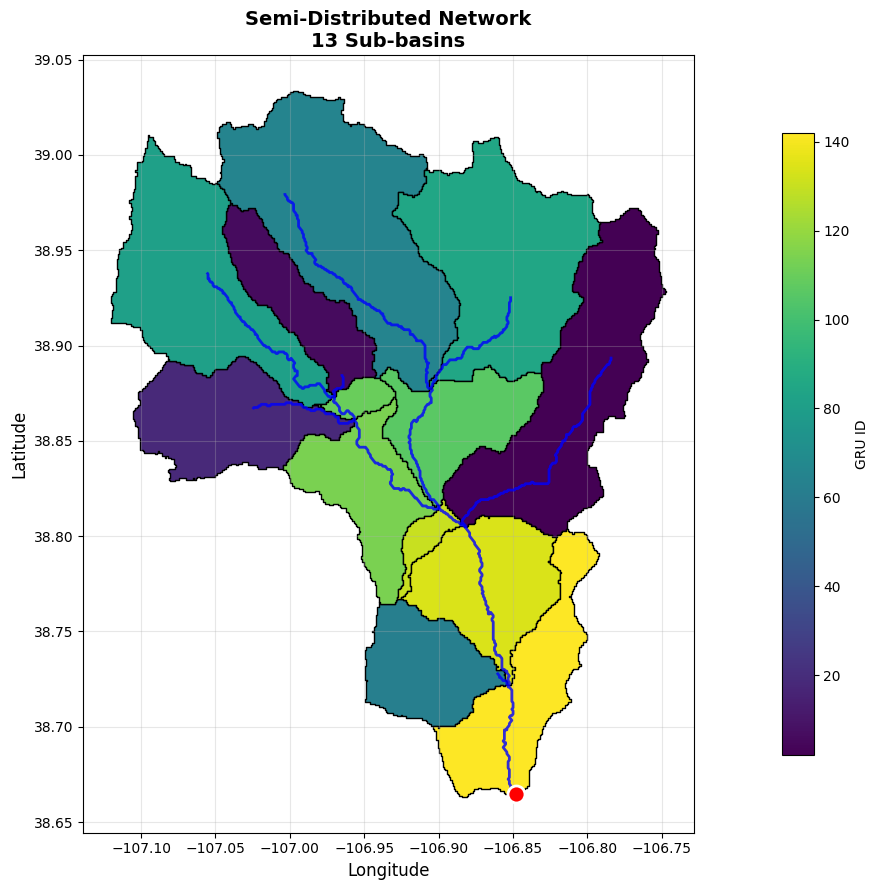

In [15]:
# Load and analyze created spatial products
basin_dir = project_dir / 'shapefiles' / 'river_basins'
network_dir = project_dir / 'shapefiles' / 'river_network'
catchment_dir = project_dir / 'shapefiles' / 'catchment'

# Load spatial data
basin_files = list(basin_dir.glob('*.shp'))
network_files = list(network_dir.glob('*.shp'))

basins_gdf = gpd.read_file(basin_files[0])
network_gdf = gpd.read_file(network_files[0])

# Project to appropriate CRS for area calculations
# For East River at Banff (Alberta), UTM Zone 11N is appropriate
target_crs = 'EPSG:32611'  # UTM Zone 11N
basins_projected = basins_gdf.to_crs(target_crs)

print(f"\n📋 Network Structure Summary:")
print(f"   Sub-basins (GRUs): {len(basins_gdf)}")
print(f"   Stream segments: {len(network_gdf)}")

# Calculate areas using projected geometries
total_area_m2 = basins_projected.geometry.area.sum()
total_area_km2 = total_area_m2 / 1e6
avg_gru_size_km2 = total_area_km2 / len(basins_gdf)

print(f"   Total watershed area: {total_area_km2:.1f} km²")
print(f"   Average GRU size: {avg_gru_size_km2:.1f} km²")

# Analyze GRU characteristics
if 'elevation' in basins_gdf.columns:
    print(f"   Elevation range: {basins_gdf['elevation'].min():.0f}m to {basins_gdf['elevation'].max():.0f}m")
    print(f"   Elevation gradient: {basins_gdf['elevation'].max() - basins_gdf['elevation'].min():.0f}m span")

# Stream network characteristics
if 'Length' in network_gdf.columns:
    total_length = network_gdf['Length'].sum() / 1000  # Convert to km
    print(f"   Total stream length: {total_length:.1f} km")

print(f"\n🗺️  Creating network structure visualization...")

fig, axes = plt.subplots(figsize=(18, 9))

# Left plot: Sub-basin network with elevation (use original CRS for plotting)
ax1 = axes

if 'elevation' in basins_gdf.columns:
    # Color by elevation
    basins_plot = basins_gdf.plot(ax=ax1, column='elevation', cmap='terrain',
                                edgecolor='black', linewidth=1, legend=True,
                                legend_kwds={'label': 'Elevation (m)', 'shrink': 0.8})
else:
    # Color by GRU ID
    basins_plot = basins_gdf.plot(ax=ax1, column='GRU_ID', cmap='viridis',
                                edgecolor='black', linewidth=1, legend=True,
                                legend_kwds={'label': 'GRU ID', 'shrink': 0.8})

# Add stream network
network_gdf.plot(ax=ax1, color='blue', linewidth=2, alpha=0.8)

# Add pour point
pour_point_gdf = gpd.read_file(pour_point_path)
pour_point_gdf.plot(ax=ax1, color='red', markersize=150, marker='o',
                   edgecolor='white', linewidth=2, zorder=5)

ax1.set_title(f'Semi-Distributed Network\n{len(basins_gdf)} Sub-basins', 
             fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.grid(True, alpha=0.3)



plt.tight_layout()
plt.show()

## Step 3: Multi-GRU Data Pipeline
The same model-agnostic preprocessing framework now scales to multiple connected sub-basins, demonstrating CONFLUENCE's seamless transition from single-unit to multi-unit spatial modeling. The core data quality and standardization principles remain unchanged; however, spatial processing now handles distributed forcing across the GRU network and routing connectivity between sub-basins.

The same preprocessing philosophy ensures consistent data standards across spatial scales, enabling robust model intercomparison and maintaining the scientific rigor established in previous tutorials.

In [7]:
# Execute streamflow data processing 
confluence.managers['data'].process_observed_data()
print("✅ Streamflow validation data ready")

18:16:06 ● Processing observed data
18:16:06 ● Processing USGS streamflow data directly from API
18:16:06 ● Retrieving discharge data for station 09112500
18:16:06 ● Time period: 2016-01-02 to 2025-09-14
18:16:06 ● Converting from cfs to cms using factor: 0.0283168
18:16:06 ● Using formatted start date: 2016-01-02
18:16:06 ● Using formatted end date: 2025-09-14
18:16:06 ● Fetching data from: https://nwis.waterservices.usgs.gov/nwis/dv/?site=09112500&format=rdb&parameterCd=00060&startDT=2016-01-02&endDT=2025-09-14


KeyboardInterrupt: 

In [6]:
# Check if forcing data was copied, otherwise acquire
forcing_dir = project_dir / 'forcing' / 'merged_data'
if not forcing_dir.exists() or len(list(forcing_dir.glob('*.nc'))) == 0:
    # confluence.managers['data'].acquire_forcings()
    print("✅ Forcing acquisition complete (simulated)")

In [12]:
# Execute model-agnostic preprocessing
confluence.managers['data'].run_model_agnostic_preprocessing()
print("✅ Multi-GRU preprocessing complete")

14:09:34 ● Starting model-agnostic preprocessing
14:09:34 ● Running geospatial statistics
14:09:34 ● Starting geospatial statistics calculation
14:09:34 ● Soil statistics already calculated: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment_intersection/with_soilgrids/catchment_with_soilclass.shp
14:09:34 ● Land statistics already calculated: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment_intersection/with_landclass/catchment_with_landclass.shp
14:09:34 ● Elevation statistics already calculated: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment_intersection/with_dem/catchment_with_dem.shp
14:09:34 ● Geospatial statistics completed: 3/3 steps skipped, 0/3 steps executed
14:09:34 ● Running forcing resampling
14:09:34 ● Starting forcing data resampling process
14:09:34 ● Creating ERA5 shapefile
14:09:34 ● Forcing shapefile already exists: /scratch/dlhogan/ess-project-data/domain_Eas

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field GRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field GRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field HRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field HRU_area of feature 4 not successfully written. Pos

EASYMORE saved target shapefile for EASYMORE claculation as:EASYMORE saved target shapefile for EASYMORE claculation as:

./East_River_distributed_ERA5_target_shapefile.shp./East_River_distributed_ERA5_target_shapefile.shp



/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field GRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


EASYMORE detects case 1 - regular lat/lon

...

EASYMORE detects that the variables from the netCDF files are identicalin dimensions of the variables and latitude and longitude
EASYMORE detects that all the variables have dimensions of:
['time', 'latitude', 'longitude']
EASYMORE detects that the longitude variables has dimensions of:
['longitude']
EASYMORE detects that the latitude variables has dimensions of:
['latitude']
--CREATING-REMAPPING-FILE--
Started at date and time 2025-09-11 14:19:46.276749
EASYMORE detects that target shapefile is in WGS84 (epsg:4326)
EASYMORE detects that the field for ID is provided in sink/target shapefile
EASYMORE detects that the field latitude is provided in sink/target shapefile
EASYMORE detects that the field longitude is provided in sink/target shapefile
it seems everything is OK with the sink/target shapefile; added to EASYMORE object target_shp_gpd


/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field GRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field HRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


EASYMORE saved target shapefile for EASYMORE claculation as:
./East_River_distributed_ERA5_target_shapefile.shp
EASYMORE detects case 1 - regular lat/lon
./East_River_distributed_ERA5_source_shapefile.shp
EASYMORE created the shapefile from the netCDF file and saved it here:
EASMORE detects that target shapefile is inside the boundary of source netCDF file  and therefore correction for longitude values -180 to 180 or 0 to 360 is not performed even if  the correction_shp_lon flag is set to True [default is True]


/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field GRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field HRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field GRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field HRU_area of feature 4 not successfully written. Pos

Ended at date and time 2025-09-11 14:19:46.531988
It took 0.255239 seconds to finish creating of the remapping file
---------------------------
------REMAPPING------
netcdf output file will be compressed at level 4
Remapping /scratch/dlhogan/ess-project-data/domain_East_River_distributed/forcing/merged_data/ERA5_merged_201909.nc to /scratch/dlhogan/ess-project-data/domain_East_River_distributed/forcing/basin_averaged_data/East_River_distributed_ERA5_remapped_ERA5_merged_201909.nc 
Started at date and time 2025-09-11 14:19:28.991887 
Ended at date and time 2025-09-11 14:19:48.837721 
It took 19.845834 seconds to finish the remapping of variable(s) 
---------------------
---------------------
14:19:48 ● Worker 2: Successfully processed ERA5_merged_201909.nc in 20.38 seconds
Remapping /scratch/dlhogan/ess-project-data/domain_East_River_distributed/forcing/merged_data/ERA5_merged_201910.nc to /scratch/dlhogan/ess-project-data/domain_East_River_distributed/forcing/basin_averaged_data/East_R

In [9]:
# Execute model-specific preprocessing
confluence.managers['model'].preprocess_models()
print("✅ Semi-distributed model configuration complete")

18:21:39 ● Starting model-specific preprocessing
18:21:39 ● Processing model: SUMMA
18:21:39 ● Starting SUMMA spatial preprocessing
18:21:39 ● Starting memory-efficient temperature lapse rate and data step application
18:21:39 ● Loading topology data...


18:21:39 ● Loaded topology data: 26 rows, 0.18 MB
18:21:39 ● Found 120 forcing files to process
18:21:39 ● Pre-calculating lapse rate corrections...
18:21:40 ● Prepared lapse corrections for 13 HRUs
18:21:40 ● Processing files in batches of 100
18:21:57 ● Completed processing of 120 ERA5 forcing files with temperature lapsing
18:21:57 ● Copying SUMMA base settings
18:21:57 ● SUMMA base settings copied to /scratch/dlhogan/ess-project-data/domain_East_River_distributed/settings/SUMMA
18:21:57 ● Creating SUMMA file manager
18:21:57 ● SUMMA file manager created at /scratch/dlhogan/ess-project-data/domain_East_River_distributed/settings/SUMMA/fileManager.txt
18:21:57 ● Creating forcing file list
18:21:57 ● Found 120 ERA5 forcing files
18:21:57 ● Forcing file list created at /scratch/dlhogan/ess-project-data/domain_East_River_distributed/settings/SUMMA/forcingFileList.txt with 120 files
18:21:57 ● Creating initial conditions (cold state) file
18:21:57 ● Creating initial conditions (cold stat

## Step 4: Streamlined Semi-Distributed Model Execution
The same SUMMA process-based physics now executes across multiple connected sub-basins, representing an advance in spatial modeling complexity. This integration of distributed runoff generation with explicit network routing demonstrates how the same computational framework scales from single-unit to multi-unit watershed simulation while maintaining physical realism and computational efficiency. The same workflow orchestration ensures robust execution across this increased complexity while mizuRoute integration transforms the distributed runoff into realistic streamflow with routing delays and channel storage effects.

In [10]:
# Execute the semi-distributed model system

confluence.managers['model'].run_models()
routing_dir = confluence.project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "mizuRoute"
routing_files = list(routing_dir.glob("*.nc"))
if not routing_files:
    mizuRoute_run_status = False
    print("⚠️  mizuRoute likely broke - run linear reservoir routing instead")
else:
    mizuRoute_run_status = True
    print("✅ model completed successfully")


18:22:13 ● Starting model runs
18:22:13 ● Running model: SUMMA
18:22:13 ● Starting SUMMA run


18:24:26 ● SUMMA run completed successfully
18:24:26 ● Starting mizuRoute run
18:24:26 ● mizuRoute run failed with error: Command '/home/dlhogan/tools/src/mizuRoute/route/bin/route_runoff /scratch/dlhogan/ess-project-data/domain_East_River_distributed/settings/mizuRoute/mizuroute.control' returned non-zero exit status 30.
18:24:26 ● Error during SUMMA model run: Command '/home/dlhogan/tools/src/mizuRoute/route/bin/route_runoff /scratch/dlhogan/ess-project-data/domain_East_River_distributed/settings/mizuRoute/mizuroute.control' returned non-zero exit status 30.
18:24:26 ● Traceback (most recent call last):
  File "/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/utils/models/model_manager.py", line 262, in run_models
    mizuroute_runner.run_mizuroute()
  File "/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/utils/models/mizuroute_utils.py", line 395, in run_mizuroute
    subprocess.run(mizu_command, shell=True, check=True, stdout=log_file, stderr=subprocess.STDOUT)
 

### Step 4b: Alternative Cascade of Linear Reservoir Routing

In [20]:
import numpy as np
from collections import deque

def route_modeled_outflows_cascade(Q_modeled, downstream, length_m, slope, dt,
                                   K=None,
                                   K_scale=1.0,
                                   mannings_n=0.04,
                                   depth_m=0.4,
                                   n_cascade=2,
                                   delay_steps=None):
    """
    Route modeled outflows from sub-basins through a directed network where each reach
    is represented as a cascade of linear reservoirs.
    
    Inputs:
      - Q_modeled: (n_reach, n_t) array of modeled outflow (m3/s) — treated as inflow to routing element.
      - downstream: length-n_reach array of downstream indices (-1 for global outlet).
      - length_m, slope: arrays length n_reach.
      - dt: timestep in seconds.
      - K: optional array of reservoir timescale (seconds) per reach. If None, estimate via Manning.
      - K_scale: scalar multiplier applied to K (easy tuning).
      - mannings_n, depth_m: used if K is None (defaults reasonable for mountain streams).
      - n_cascade: scalar or array (# of linear reservoirs per reach). can be int or array-like.
      - delay_steps: optional integer-array per reach specifying a pure integer-step delay (in time-steps)
                     to apply instead of/alongside cascade. If provided, it's used as an extra FIFO delay.
    Returns:
      - Q_routed: (n_reach, n_t) routed outflow time series at the downstream end of each reach.
      - K_used: array of K actually used (seconds).
    """
    Q = np.array(Q_modeled, dtype=float)
    n_reach, n_t = Q.shape

    # n_cascade handling
    if np.isscalar(n_cascade):
        n_cascade_arr = np.full(n_reach, int(n_cascade), dtype=int)
    else:
        n_cascade_arr = np.array(n_cascade, dtype=int)

    # estimate K if not provided
    if K is None:
        K = np.zeros(n_reach, dtype=float)
        for i in range(n_reach):
            Si = max(slope[i], 1e-9)
            R = max(depth_m, 0.01)
            V = (1.0 / mannings_n) * (R ** (2.0/3.0)) * np.sqrt(Si)
            V = max(V, 1e-6)
            K[i] = max(length_m[i] / V, 1.0)
    else:
        K = np.array(K, dtype=float)

    K_used = K * float(K_scale)
    # avoid zeros
    K_used = np.maximum(K_used, 1e-6)

    # build topo ordering
    indeg = np.zeros(n_reach, dtype=int)
    for i, d in enumerate(downstream):
        if 0 <= d < n_reach:
            indeg[d] += 1
    q = deque([i for i in range(n_reach) if indeg[i] == 0])
    topo = []
    while q:
        u = q.popleft()
        topo.append(u)
        d = downstream[u]
        if 0 <= d < n_reach:
            indeg[d] -= 1
            if indeg[d] == 0:
                q.append(d)
    if len(topo) != n_reach:
        raise ValueError("Network invalid or contains cycle.")

    # Precompute per-reservoir alpha for each reach
    alphas = np.zeros(n_reach, dtype=float)
    for i in range(n_reach):
        m = max(1, n_cascade_arr[i])
        K_r = K_used[i] / m
        alphas[i] = np.exp(-dt / K_r)

    # If delay_steps provided, create buffers
    if delay_steps is not None:
        delay_steps = np.array(delay_steps, dtype=int)
        buffers = [deque([0.0]*(int(delay_steps[i]) + 1), maxlen=int(delay_steps[i]) + 1)
                   for i in range(n_reach)]
    else:
        buffers = None

    # storage for cascade state: Q_prev for each reservoir (use max cascade length)
    max_m = int(np.max(n_cascade_arr))
    Q_prev_res = np.zeros((n_reach, max_m), dtype=float)

    Q_routed = np.zeros_like(Q)

    # main loop: each timestep, treat Q_modeled as the inflow to the first reservoir of the reach
    for ti in range(n_t):
        # start inflow with modeled outflow at this timestep
        inflow = Q[:, ti].copy()

        # if delay buffers used, first pop from them to form inflow, but also push local modeled inflow into them
        if buffers is not None:
            # for causal consistency, first add current modeled inflow to buffers then set inflow to popped values
            for i in range(n_reach):
                buffers[i].append(inflow[i])
            # now replace inflow with buffer pop
            inflow = np.array([buffers[i].popleft() for i in range(n_reach)])

        # route in topo order (so upstream contributions reach downstream inflow same timestep)
        for g in topo:
            m = n_cascade_arr[g]
            a = alphas[g]
            # push inflow through cascade of m linear reservoirs (outflow of each reservoir becomes inflow to next)
            I = inflow[g]
            for r in range(m):
                Q_new = a * Q_prev_res[g, r] + (1.0 - a) * I
                Q_prev_res[g, r] = Q_new
                I = Q_new
            Q_routed[g, ti] = I  # final reservoir outflow

            # add routed outflow to downstream inflow for this timestep (causal)
            d = downstream[g]
            if 0 <= d < n_reach:
                inflow[d] += Q_routed[g, ti]

    return Q_routed, K_used

In [21]:
def map_downstream_ids_to_indices(downstream_ids, reach_ids):
    """
    Map downstream values (GRU IDs) to zero-based indices matching reach_ids order.
    - downstream_ids: array length n_reach, values are GRU IDs (or -1 for outlet).
    - reach_ids:     array length n_reach, reach ID for each row (must match Q_modeled order).
    Returns an int array downstream_idx of same length with values in [-1..n_reach-1].
    """
    downstream_ids = np.asarray(downstream_ids)
    reach_ids = np.asarray(reach_ids)
    if reach_ids.shape[0] != downstream_ids.shape[0]:
        raise ValueError("reach_ids must be same length as downstream_ids / n_reach")

    id_to_idx = {rid: i for i, rid in enumerate(reach_ids)}
    downstream_idx = np.full_like(downstream_ids, fill_value=-1, dtype=int)

    missing = set()
    for i, d in enumerate(downstream_ids):
        if d == -1:
            downstream_idx[i] = -1
            continue
        # If downstream value equals this reach's own id, treat as outlet/self -> -1
        if d == reach_ids[i]:
            downstream_idx[i] = -1
            continue
        if d in id_to_idx:
            downstream_idx[i] = id_to_idx[d]
        else:
            # not found in reach_ids -> set to -1 (treat as outlet) and record for debug
            downstream_idx[i] = -1
            missing.add(d)

    if missing:
        print("Warning: these downstream IDs were not found in reach_ids and were set to -1:", missing)
    return downstream_idx


#### Apply routing scheme.

In [23]:
# Load observed streamflow (same as lumped model for direct comparison)
obs_path = confluence.project_dir / "observations" / "streamflow" / "preprocessed" / f"{config_dict['DOMAIN_NAME']}_streamflow_processed.csv"
obs_df = pd.read_csv(obs_path, parse_dates=['datetime'])
obs_df.set_index('datetime', inplace=True)

if not mizuRoute_run_status:
    # Load semi-distributed simulation from SUMMA
    summa_sim_dir = confluence.project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "SUMMA"
    summa_sim_files = list(summa_sim_dir.glob('*.nc'))

    # Load SUMMA output
    summa_sim_ds = xr.open_dataset(summa_sim_files[0])

    # Load network topology
    topology_file = project_dir / "settings" / "mizuRoute" / "topology.nc"
    topology_ds = xr.open_dataset(topology_file)

    # Extract discharge time series
    Q_modeled = summa_sim_ds['averageRoutedRunoff'].transpose('gru', 'time').values # (n_reach, n_time)

    # Convert from m/s to m3/s by multiplying by area
    Q_modeled =  Q_modeled * topology_ds["area"].values[:, np.newaxis]  # (n_reach, n_time)

    # --- Extract topology & geometry ---
    downstream = map_downstream_ids_to_indices(topology_ds["downSegId"].values.astype(int), topology_ds["segId"].values.astype(int))
    length_m   = topology_ds["length"].values
    slope      = topology_ds["slope"].values

    # --- Time step (seconds) ---
    time = summa_sim_ds["time"].values
    # compute dt from first two timestamps (assumes regular spacing)
    dt = (np.diff(time).astype("timedelta64[s]")[0]).astype(int)
    print(f"Simulation time step: {dt} seconds")

    Q_routed, K_used = route_modeled_outflows_cascade(
    Q_modeled=Q_modeled,
    downstream=downstream,
    length_m=length_m,
    slope=slope,
    dt=dt,
    n_cascade=2,
    K_scale=10.0
    )

    # Identify outlet hydrograph
    outlet_idx = np.where(downstream == -1)[0][0]
    Q_outlet = Q_routed[outlet_idx, :]

    routing_da = xr.DataArray(
        Q_routed,
        dims=("gru", "time"),
        coords={"gru": summa_sim_ds["gru"], "time": summa_sim_ds["time"].values},
        name="IRFroutedRunoff"
    )

    routing_ds = routing_da.to_dataset()

    # add in Q_outlet as another gru
    routing_ds['Q_outlet'] = (('time',), Q_outlet)

Simulation time step: 3600 seconds


Rerouting example...
K used per GRU (s): [ 6684.78279494  8715.39623001  1545.45905817  7433.62982136
  3548.57424314  5973.00344922 11572.00949009 11278.75245428
  3869.04379003   683.18702571  3759.05294669   888.92714635
  7260.16793282]


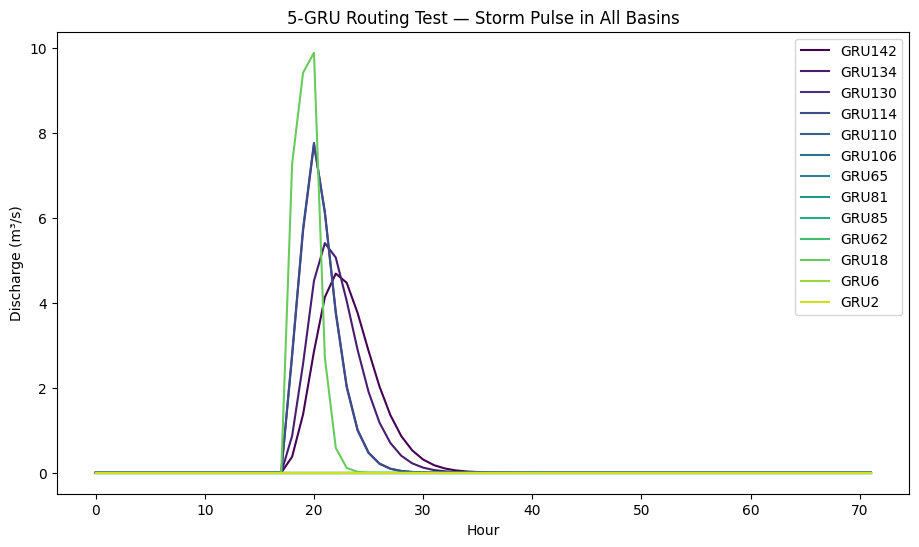

Outlet peak flow: 4.687853788969617
Outlet peak hour: 22


In [24]:
print("Rerouting example...")
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# ---------- Network topology ----------
n_reach = 13              

downstream = map_downstream_ids_to_indices(
    topology_ds["downSegId"].values.astype(int),
    topology_ds["segId"].values.astype(int)
)
length_m   = topology_ds["length"].values
slope      = topology_ds["slope"].values

# ---------- Create inflow time series ----------
dt = 3600                     # 1-hour
n_t = 24*3                    # 3 days
# initialize with baseflows increasing downstream for the 13 GRUs
Q_modeled = np.zeros((n_reach, n_t))

# Add a 3-hour, 10 m³/s storm pulse to last 3 basins at hour 18
Q_modeled[-3,18:21] = 10.0


# ---------- Run routing ----------
Q_routed, K_used = route_modeled_outflows_cascade(
    Q_modeled,
    downstream=downstream,
    length_m=length_m,
    slope=slope,
    dt=dt,
    n_cascade=2,
    K_scale=1.0
)

# ---------- Diagnostics ----------
print("K used per GRU (s):", K_used)

time = np.arange(n_t)
plt.figure(figsize=(11,6))
cmap = plt.get_cmap("viridis")
for i in range(n_reach):
    plt.plot(time, Q_routed[i], label=f"GRU{topology_ds['segId'].values[i]}", color=cmap(i/n_reach))
plt.xlabel("Hour")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.title("5-GRU Routing Test — Storm Pulse in All Basins")
plt.show()

print("Outlet peak flow:", Q_routed[0].max())
print("Outlet peak hour:", np.argmax(Q_routed[0]))


## Step 5: Evaluation and Performance Comparison

In [25]:
# Load observed streamflow (same as lumped model for direct comparison)
obs_path = confluence.project_dir / "observations" / "streamflow" / "preprocessed" / f"{config_dict['DOMAIN_NAME']}_streamflow_processed.csv"
obs_df = pd.read_csv(obs_path, parse_dates=['datetime'])
obs_df.set_index('datetime', inplace=True)


In [26]:
# Load semi-distributed simulation from mizuRoute
routing_dir = confluence.project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "mizuRoute"
routing_files = list(routing_dir.glob("*.nc"))

if routing_files:
    # Load mizuRoute network output
    routing_ds = xr.open_dataset(routing_files[0])
    
    # Extract outlet streamflow (typically the downstream-most segment)
    if 'IRFroutedRunoff' in routing_ds.data_vars:
        # Find outlet segment (could be identified by SIM_REACH_ID or maximum downstream position)
        reach_id = int(config_dict.get('SIM_REACH_ID', routing_ds.reachID.values[-1]))
        
        # Find segment index for outlet
        segment_indices = np.where(routing_ds.reachID.values == reach_id)[0]
        
        if len(segment_indices) > 0:
            segment_idx = segment_indices[0]
            sim_streamflow = routing_ds['IRFroutedRunoff'].isel(seg=segment_idx)
            sim_df = sim_streamflow.to_pandas()
                        
        else:
            print(f"⚠️  Outlet segment {reach_id} not found")
            sim_df = None
    else:
        print(f"⚠️  Streamflow variable not found in routing output")
        sim_df = None
        
    routing_ds.close()
else:
    print(f"⚠️  mizuRoute output not found")
    print(f" Using linear reservoir routing instead...")
    if config_dict['SIM_REACH_ID'] == routing_ds.gru.values[-1]:
        reach_id = int(config_dict.get('SIM_REACH_ID', routing_ds.gru.values[-1]))
    else:
        reach_id = routing_ds.gru.values[-1]

    # Find segment index for outlet
    segment_indices = np.where(routing_ds.gru.values == reach_id)[0]
    sim_df = routing_ds['Q_outlet'].to_pandas()


⚠️  mizuRoute output not found
 Using linear reservoir routing instead...


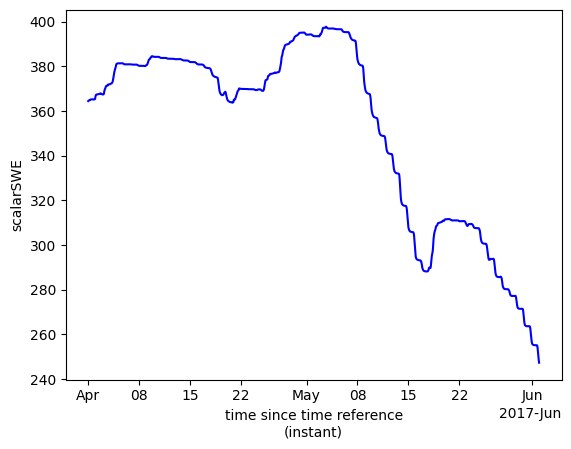

In [35]:
summa_sim_ds['scalarSWE'].sel(time=slice('2017-04-01', '2017-06-01')).mean(dim='hru').plot(label='SUMMA SWE', color='blue')


📈 Semi-Distributed Performance Metrics:
   📊 RMSE: 9.19 m³/s
   📊 Bias: +0.09 m³/s (+1.3%)
   📊 MAE: 5.65 m³/s
   📊 Correlation (r): 0.626
   📊 Nash-Sutcliffe (NSE): 0.375
   📊 Kling-Gupta (KGE): 0.553

📊 Flow Regime Assessment:
   High flows (Q95): Obs=31.5, Sim=19.8 m³/s (-37.1%)
   Medium flows (Q50): Obs=2.7, Sim=4.1 m³/s (+53.5%)
   Low flows (Q05): Obs=1.6, Sim=1.7 m³/s (+8.7%)

📈 Creating semi-distributed evaluation visualization...


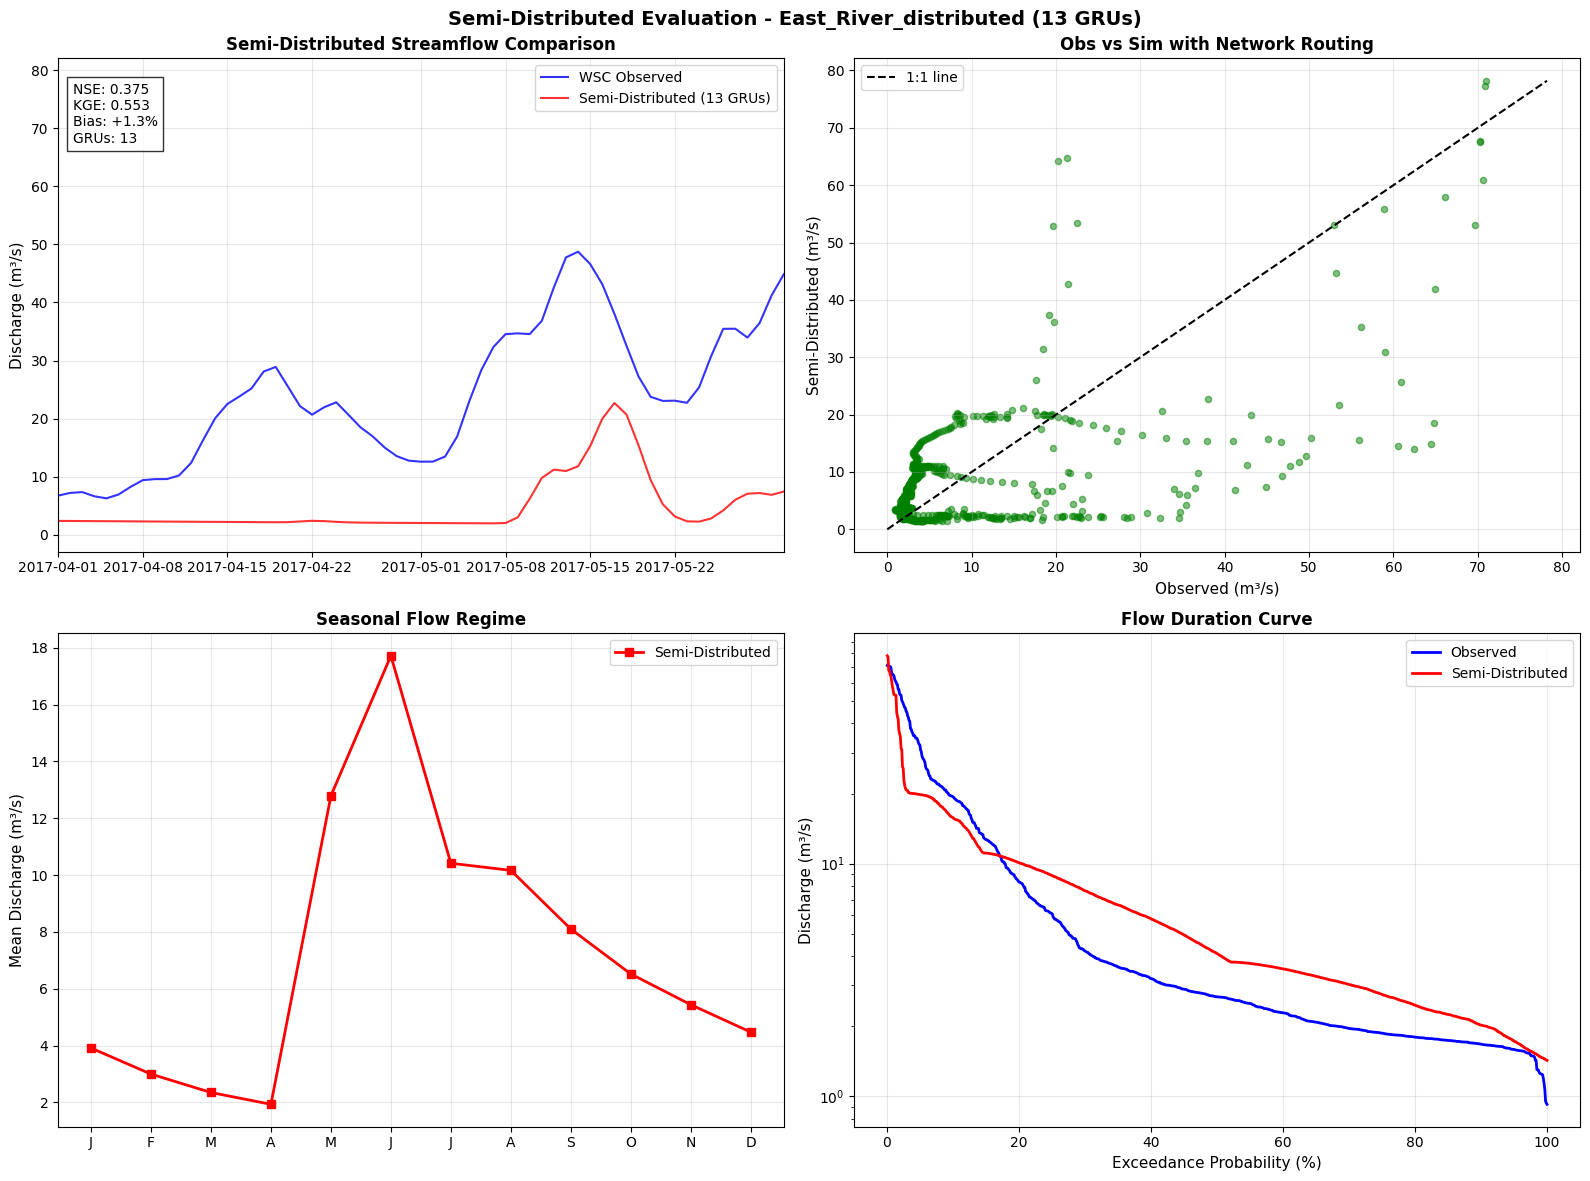

In [28]:

# =============================================================================
# SEMI-DISTRIBUTED PERFORMANCE ASSESSMENT
# =============================================================================
    
# Align data to common period
start_date = max(obs_df.index.min(), sim_df.index.min())
end_date = min(obs_df.index.max(), sim_df.index.max())

# Skip initial spinup period
start_date = start_date + pd.DateOffset(months=6)

# Resample to daily and filter to common period
obs_daily = obs_df['discharge_cms'].resample('D').mean().loc[start_date:end_date]
sim_daily = sim_df.resample('D').mean().loc[start_date:end_date]

# Remove NaN values
valid_mask = ~(obs_daily.isna() | sim_daily.isna())
obs_valid = obs_daily[valid_mask]
sim_valid = sim_daily[valid_mask]

# Calculate comprehensive performance metrics
print(f"\n📈 Semi-Distributed Performance Metrics:")

# Basic statistics
rmse = np.sqrt(((obs_valid - sim_valid) ** 2).mean())
bias = (sim_valid - obs_valid).mean()
mae = np.abs(obs_valid - sim_valid).mean()
pbias = 100 * bias / obs_valid.mean()

# Efficiency metrics
nse = 1 - ((obs_valid - sim_valid) ** 2).sum() / ((obs_valid - obs_valid.mean()) ** 2).sum()

# Kling-Gupta Efficiency
r = obs_valid.corr(sim_valid)
alpha = sim_valid.std() / obs_valid.std()
beta = sim_valid.mean() / obs_valid.mean()
kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

# Display performance metrics
print(f"   📊 RMSE: {rmse:.2f} m³/s")
print(f"   📊 Bias: {bias:+.2f} m³/s ({pbias:+.1f}%)")
print(f"   📊 MAE: {mae:.2f} m³/s")
print(f"   📊 Correlation (r): {r:.3f}")
print(f"   📊 Nash-Sutcliffe (NSE): {nse:.3f}")
print(f"   📊 Kling-Gupta (KGE): {kge:.3f}")

# =============================================================================
# ROUTING AND SPATIAL EFFECTS ANALYSIS
# =============================================================================

# Analyze peak flow timing (routing delay effects)
obs_peaks = obs_valid[obs_valid > obs_valid.quantile(0.95)]
sim_peaks = sim_valid[sim_valid > sim_valid.quantile(0.95)]

if len(obs_peaks) > 0 and len(sim_peaks) > 0:
    # Find largest peak in common period
    obs_max_date = obs_valid.idxmax()
    sim_max_date = sim_valid.idxmax()
    peak_timing_diff = (sim_max_date - obs_max_date).days
    
# Flow regime analysis
flow_stats = {
    'High flows (Q95)': (obs_valid.quantile(0.95), sim_valid.quantile(0.95)),
    'Medium flows (Q50)': (obs_valid.quantile(0.50), sim_valid.quantile(0.50)),
    'Low flows (Q05)': (obs_valid.quantile(0.05), sim_valid.quantile(0.05))
}

print(f"\n📊 Flow Regime Assessment:")
for regime, (obs_q, sim_q) in flow_stats.items():
    bias_pct = 100 * (sim_q - obs_q) / obs_q
    print(f"   {regime}: Obs={obs_q:.1f}, Sim={sim_q:.1f} m³/s ({bias_pct:+.1f}%)")

# =============================================================================
# COMPREHENSIVE SEMI-DISTRIBUTED VISUALIZATION
# =============================================================================

print(f"\n📈 Creating semi-distributed evaluation visualization...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Time series comparison (top left)
ax1 = axes[0, 0]
ax1.plot(obs_valid.index, obs_valid.values, 'b-',
         label='WSC Observed', linewidth=1.5, alpha=0.8)
ax1.plot(sim_valid.index, sim_valid.values, 'r-',
         label=f'Semi-Distributed ({len(basins_gdf)} GRUs)', linewidth=1.5, alpha=0.8)

ax1.set_ylabel('Discharge (m³/s)', fontsize=11)
ax1.set_title('Semi-Distributed Streamflow Comparison', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim([datetime(2017,4,1), datetime(2017,5,31)])

# Add performance metrics
metrics_text = f'NSE: {nse:.3f}\nKGE: {kge:.3f}\nBias: {pbias:+.1f}%\nGRUs: {len(basins_gdf)}'
ax1.text(0.02, 0.95, metrics_text, transform=ax1.transAxes,
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10, verticalalignment='top')

# Scatter plot with routing emphasis (top right)
ax2 = axes[0, 1]
ax2.scatter(obs_valid, sim_valid, alpha=0.5, c='green', s=20)
max_val = max(obs_valid.max(), sim_valid.max())
ax2.plot([0, max_val], [0, max_val], 'k--', label='1:1 line')
ax2.set_xlabel('Observed (m³/s)', fontsize=11)
ax2.set_ylabel('Semi-Distributed (m³/s)', fontsize=11)
ax2.set_title('Obs vs Sim with Network Routing', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Monthly climatology (bottom left)
ax3 = axes[1, 0]
# monthly_obs = obs_valid.groupby(obs_valid.index.month).mean()
monthly_sim = sim_valid.groupby(sim_valid.index.month).mean()
months = range(1, 13)
month_names = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

# ax3.plot(months, monthly_obs.values, 'o-', label='Observed',
#          color='blue', linewidth=2, markersize=6)
ax3.plot(months, monthly_sim.values, 's-', label='Semi-Distributed',
         color='red', linewidth=2, markersize=6)

ax3.set_xticks(months)
ax3.set_xticklabels(month_names)
ax3.set_ylabel('Mean Discharge (m³/s)', fontsize=11)
ax3.set_title('Seasonal Flow Regime', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Flow duration curve (bottom right)
ax4 = axes[1, 1]

# Calculate exceedance probabilities
obs_sorted = obs_valid.sort_values(ascending=False)
sim_sorted = sim_valid.sort_values(ascending=False)
obs_ranks = np.arange(1., len(obs_sorted) + 1) / len(obs_sorted) * 100
sim_ranks = np.arange(1., len(sim_sorted) + 1) / len(sim_sorted) * 100

ax4.semilogy(obs_ranks, obs_sorted, 'b-', label='Observed', linewidth=2)
ax4.semilogy(sim_ranks, sim_sorted, 'r-', label='Semi-Distributed', linewidth=2)

ax4.set_xlabel('Exceedance Probability (%)', fontsize=11)
ax4.set_ylabel('Discharge (m³/s)', fontsize=11)
ax4.set_title('Flow Duration Curve', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'Semi-Distributed Evaluation - {config_dict["DOMAIN_NAME"]} ({len(basins_gdf)} GRUs)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary: Semi-Distributed Basin-Scale Modeling
This tutorial successfully demonstrated the advancement from lumped to semi-distributed watershed modeling using CONFLUENCE. Through the enhanced East River at Banff case study, we illustrated how the same standardized workflow framework seamlessly scales from single-unit to multi-unit spatial representation while introducing explicit stream network routing and sub-basin connectivity, establishing the foundation for fully distributed hydrological modeling applications.

## Key Methodological Achievements
The tutorial established multi-unit spatial discretization through automated watershed delineation that creates connected sub-basins based on stream network topology and flow accumulation algorithms. Stream network routing integration was successfully implemented through mizuRoute coupling with SUMMA, enabling explicit representation of travel times and channel storage effects between connected GRUs. Intelligent data reuse capabilities were demonstrated through efficient adaptation of geospatial and forcing data from Tutorial 02a, showcasing CONFLUENCE's support for iterative model development and comparative analysis.

## Scientific Process Understanding
The evaluation demonstrated CONFLUENCE's ability to represent spatially-distributed watershed processes through multiple connected sub-basins that capture elevation gradients and heterogeneous runoff generation while maintaining integrated outlet response. Routing dynamics and timing effects were successfully simulated through explicit stream network connectivity that accounts for travel delays and channel storage in streamflow generation. Spatial process attribution capabilities were established through sub-basin-level analysis that enables identification of contributing areas and process patterns across the watershed network.

## Framework Scalability Validation
This tutorial confirmed CONFLUENCE's seamless complexity scaling by applying identical workflow principles from lumped through semi-distributed modeling without requiring fundamental architectural modifications. The model-agnostic preprocessing approach proved equally effective for multi-GRU spatial processing and routing network configuration, reinforcing the framework's broad applicability across modeling scales. Computational efficiency optimization was demonstrated through intelligent data reuse and workflow management that minimizes redundant processing while enabling rapid exploration of alternative spatial discretization strategies.
This foundation in semi-distributed basin modeling establishes essential principles for managing spatial complexity and network connectivity while preparing for the fully distributed modeling approaches and large-scale applications in subsequent tutorials.

### Next Focus: Distributed Watershed Modelling 

**Ready to explore Distributed basin simulations?** → **[Tutorial 02c: Basin Scale - Distributed Watershed](./02c_basin_distributed.ipynb)**